In [1]:
# The Setup & Data Ingestion
import sys
import os
import pandas as pd 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx 
from pyvis.network import Network 
from IPython.display import display, HTML, IFrame

# Allow notebook to see the 'src' folder
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from src.ingestor import fetch_live_market_data

# 1. Fetch live data
df = fetch_live_market_data()


2026-02-08 19:51:34,854 - INFO - ✅ Successfully ingested 10 live transactions.


In [2]:
df.head()

,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,ath_change_percentage,ath_date,atl,atl_change_percentage,atl_date,roi,last_updated,roi.times,roi.currency,roi.percentage
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,71249.000000,1426599081862,1,1426599081862,48252435413,71455.000000,...,-43.48867,2025-10-06T18:57:42.558Z,67.810000,1.049737e+05,2013-07-06T00:00:00.000Z,NaN,2026-02-08T14:20:32.082Z,NaN,NaN,NaN
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,2117.830000,256047856410,2,256047856410,32688729302,2136.130000,...,-57.18137,2025-08-24T19:21:03.333Z,0.432979,4.890302e+05,2015-10-20T00:00:00.000Z,NaN,2026-02-08T14:20:35.315Z,38.735877,btc,3873.587718
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,0.999335,185581383647,3,191044356882,84281166640,0.999485,...,-24.46905,2018-07-24T00:00:00.000Z,0.572521,7.455192e+01,2015-03-02T00:00:00.000Z,NaN,2026-02-08T14:20:34.204Z,NaN,NaN,NaN
3,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,1.460000,89168454751,4,146355304591,3064048436,1.460000,...,-59.90906,2025-07-18T03:40:53.808Z,0.002686,5.432125e+04,2014-05-22T00:00:00.000Z,NaN,2026-02-08T14:20:31.107Z,NaN,NaN,NaN
4,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,643.910000,87874653904,5,87874653904,1222953974,654.070000,...,-52.99899,2025-10-13T08:41:24.131Z,0.039818,1.617045e+06,2017-10-19T00:00:00.000Z,NaN,2026-02-08T14:20:32.028Z,NaN,NaN,NaN


In [3]:
# 2. Meta-Inspection: Inspecting columns and types
print(f"📊 Dataset Shape: {df.shape}")
print("\n--- Column Types ---")
display(df.dtypes)

📊 Dataset Shape: (10, 29)

--- Column Types ---


id                                   object
symbol                               object
name                                 object
image                                object
current_price                       float64
market_cap                            int64
market_cap_rank                       int64
fully_diluted_valuation               int64
total_volume                          int64
high_24h                            float64
low_24h                             float64
price_change_24h                    float64
price_change_percentage_24h         float64
market_cap_change_24h                 int64
market_cap_change_percentage_24h    float64
circulating_supply                  float64
total_supply                        float64
max_supply                          float64
ath                                 float64
ath_change_percentage               float64
ath_date                             object
atl                                 float64
atl_change_percentage           

In [4]:
# Convert object dates to actual datetime objects
date_cols = ['ath_date', 'atl_date', 'last_updated']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# Verify conversion
print(f"✅ Dates converted. Example 'last_updated' type: {df['last_updated'].dtype}")

✅ Dates converted. Example 'last_updated' type: datetime64[ns, UTC]


In [5]:
# 1. Identify Missing Values
missing_report = df.isnull().sum()
print("Missing Values:\n", missing_report[missing_report > 0])

# 2. Strategic Imputation
# We use Median for numeric values to stay robust against outliers
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# For categorical/ID data (like 'image'), we fill with 'unknown'
df['image'] = df['image'].fillna('unknown')

print("✅ Imputation complete using Median strategy.")

Missing Values:
 max_supply         7
roi               10
roi.times          8
roi.currency       8
roi.percentage     8
dtype: int64
✅ Imputation complete using Median strategy.


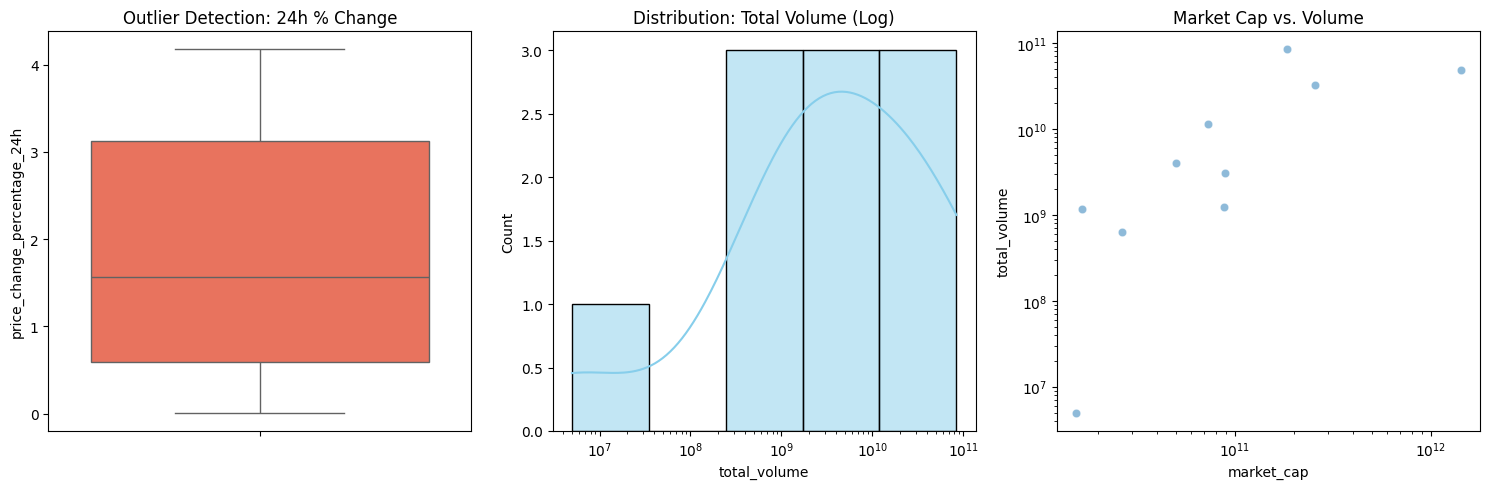

In [6]:
# Univariate Analysis (Detecting Anomaly Tails)
plt.figure(figsize=(15, 5))

# Plot A: Price Change % Outliers
plt.subplot(1, 3, 1)
sns.boxplot(y=df['price_change_percentage_24h'], color='tomato')
plt.title('Outlier Detection: 24h % Change')

# Plot B: Volume Distribution (Log Scale)
plt.subplot(1, 3, 2)
sns.histplot(df['total_volume'], kde=True, log_scale=True, color='skyblue')
plt.title('Distribution: Total Volume (Log)')

# Plot C: Market Cap vs. Volume
plt.subplot(1, 3, 3)
sns.scatterplot(x=df['market_cap'], y=df['total_volume'], alpha=0.5)
plt.xscale('log'); plt.yscale('log')
plt.title('Market Cap vs. Volume')

plt.tight_layout()
plt.show()

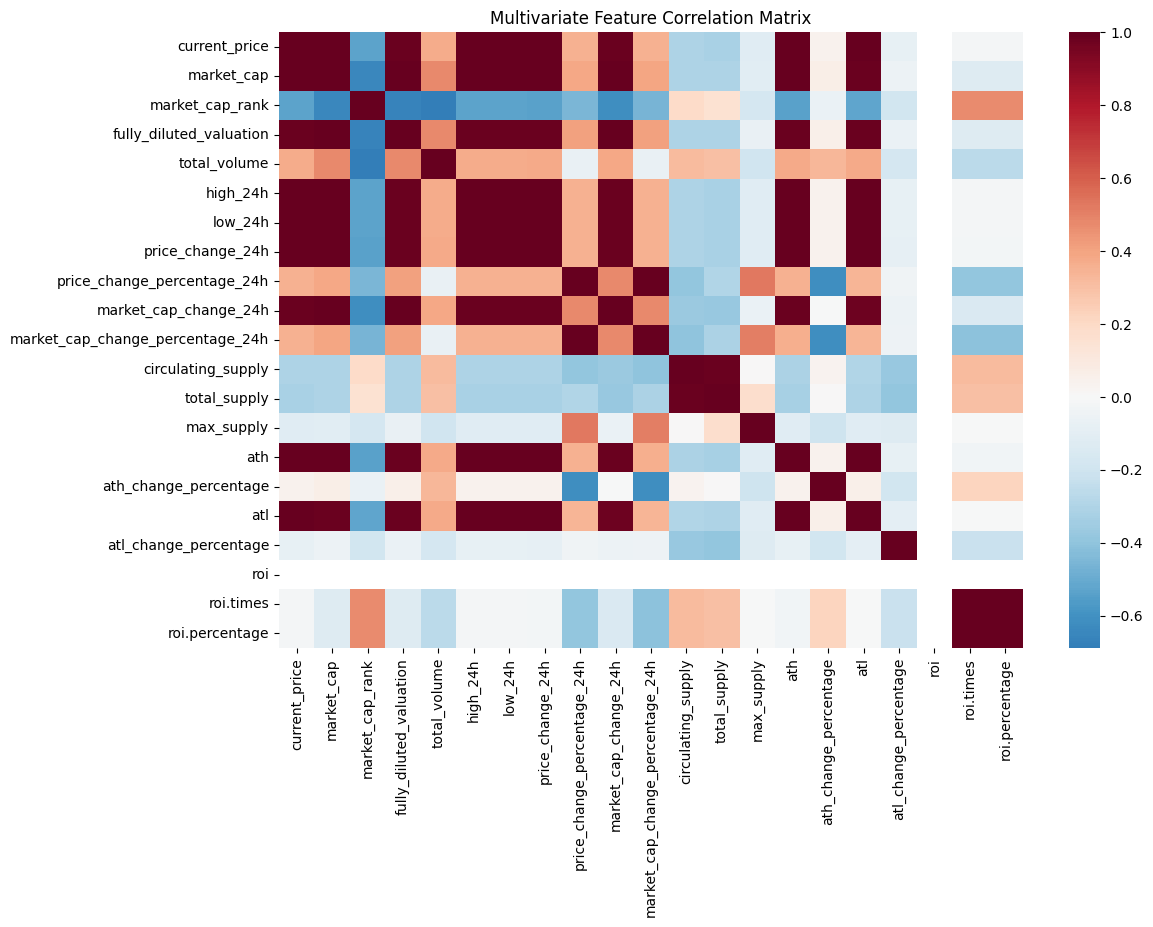

In [7]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=False, cmap='RdBu_r', center=0)
plt.title('Multivariate Feature Correlation Matrix')
plt.show()

In [8]:
# 1. Time-Based Features (Age of Asset)
df['days_since_ath'] = (pd.Timestamp.now(tz='UTC') - df['ath_date']).dt.days

# 2. Ratio Features (Liquidity & Volatility)
# High Volume + Low Market Cap = Potential Wash Trading
df['volume_mcap_ratio'] = df['total_volume'] / (df['market_cap'] + 1) 

# Spread (The gap between 24h high and low)
df['price_spread_percentage'] = (df['high_24h'] - df['low_24h']) / df['low_24h']

# 3. Log Transformations
# Financial data is highly skewed; Log scaling makes it readable for the AI
df['log_volume'] = np.log1p(df['total_volume'])
df['log_mcap'] = np.log1p(df['market_cap'])

# 4. Target Label (Proxy for Anomaly)
# We flag the top 5% of coins with suspicious volume/mcap ratios
threshold = df['volume_mcap_ratio'].quantile(0.95)
df['is_suspicious'] = (df['volume_mcap_ratio'] > threshold).astype(int)

In [9]:
required_cols = ['volume_mcap_ratio', 'current_price', 'market_cap_rank', 'price_change_percentage_24h']
missing = [col for col in required_cols if col not in df.columns]

if missing:
    print(f"❌ Missing columns: {missing}. Please re-run the Feature Engineering cell.")
else:
    print("✅ All columns present.")

✅ All columns present.


✅ Data Split: 8 training samples, 2 testing samples.


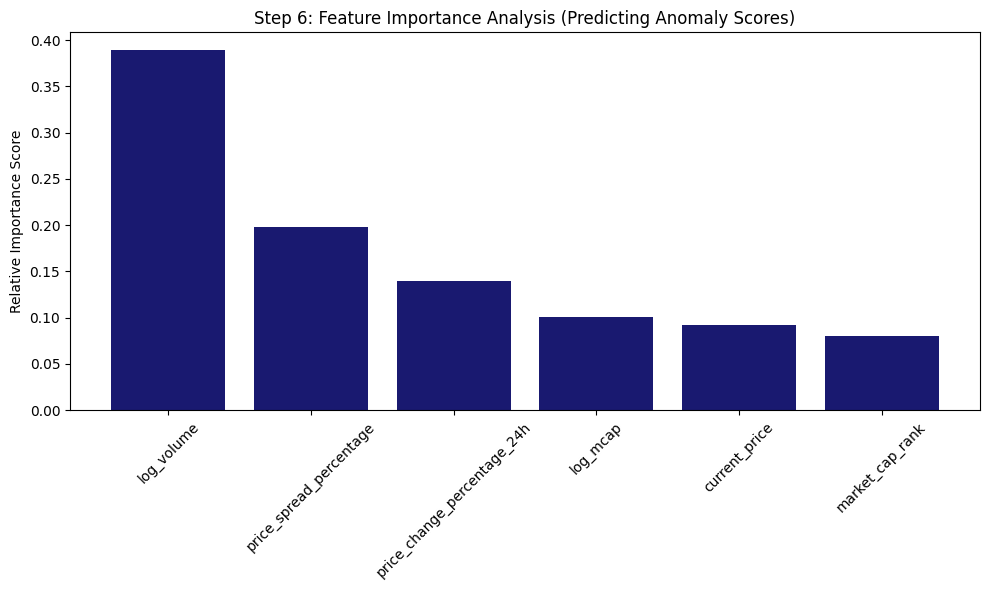

🏁 Step 6 Conclusion: The chart above shows which features the GNN should prioritize.


In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. Prepare Data for 'Importance Testing'
# We use the 'volume_mcap_ratio' we engineered as our 'Suspicion Proxy'
features = ['current_price', 'market_cap_rank', 'price_change_percentage_24h', 
            'price_spread_percentage', 'log_volume', 'log_mcap']

X = df[features]
y = df['volume_mcap_ratio']

# 2. Train-Test Split (The Professional Milestone)
# We set 20% of data aside to test if our feature importance is stable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Data Split: {len(X_train)} training samples, {len(X_test)} testing samples.")

# 3. Model Training (Diagnostic Random Forest)
rf_detector = RandomForestRegressor(n_estimators=100, random_state=42)
rf_detector.fit(X_train, y_train)

# 4. Extract Feature Importance
importances = rf_detector.feature_importances_
indices = np.argsort(importances)[::-1] # Sort in descending order

# 5. Visualize the "Decision DNA"
plt.figure(figsize=(10, 6))
plt.title("Step 6: Feature Importance Analysis (Predicting Anomaly Scores)")
plt.bar(range(X.shape[1]), importances[indices], color="midnightblue", align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.ylabel("Relative Importance Score")
plt.tight_layout()
plt.show()

print("🏁 Step 6 Conclusion: The chart above shows which features the GNN should prioritize.")

In [11]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Fit and Transform the Training Data
# The scaler "learns" the mean and std from X_train ONLY
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform the Test Data
# We use the "learned" parameters from training to scale the test data
X_test_scaled = scaler.transform(X_test)

# 4. Convert back to DataFrame for a professional look
X_train_final = pd.DataFrame(X_train_scaled, columns=features)
print("✅ Scaling Complete. All features now have Mean ≈ 0 and Std ≈ 1.")
display(X_train_final.head())

✅ Scaling Complete. All features now have Mean ≈ 0 and Std ≈ 1.


,current_price,market_cap_rank,price_change_percentage_24h,price_spread_percentage,log_volume,log_mcap
0,-0.382382,0.185695,-1.061303,-1.287576,0.515339,-0.133895
1,2.645648,-1.671258,1.200522,1.231273,1.023877,2.188955
2,-0.382412,0.928477,-0.263845,-0.430007,-0.496151,-0.925286
3,-0.382382,-0.928477,-1.049187,-1.273557,1.219870,0.596916
4,-0.382380,1.671258,-0.727934,-0.797623,-2.203142,-1.340659


In [12]:
# 1. Initialize Graph
G = nx.Graph()

for _, row in df.iterrows():
    # Red for suspicious (High Ratio), Green for normal
    node_color = "#ff4d4d" if row['is_suspicious'] == 1 else "#2ecc71"
    
    # Tooltip for professional hover-effect
    hover_label = f"Name: {row['name']}\nRank: {row['market_cap_rank']}\nPrice: ${row['current_price']}"
    
    G.add_node(row['symbol'], 
               label=row['symbol'], 
               title=hover_label, 
               color=node_color, 
               size=25 if row['is_suspicious'] == 1 else 12)

# 2. Connect Peers (Market Rank logic)
symbols = df['symbol'].tolist()
ranks = df['market_cap_rank'].tolist()
for i in range(len(symbols)):
    for j in range(i + 1, len(symbols)):
        if abs(ranks[i] - ranks[j]) <= 1:
            G.add_edge(symbols[i], symbols[j])

# 3. Setup Network with 'remote' resources 
# VS Code handles 'remote' better than 'inline' when injecting directly
try:
    net = Network(notebook=True, cdn_resources='remote', height="600px", width="100%", bgcolor="#222222", font_color="white")
except:
    net = Network(notebook=True, height="600px", width="100%", bgcolor="#222222", font_color="white")

net.from_nx(G)
net.toggle_physics(True)

# 4. THE FIX: Generate HTML and Inject Directly
file_name = "final_eda_network.html"
html_content = net.generate_html()

# Save the file (for your records/GitHub)
with open(file_name, mode='w', encoding='utf-8') as f:
    f.write(html_content)

print(f"✅ File saved to {os.path.abspath(file_name)}")

# Instead of IFrame, we inject the HTML string directly into the cell
# This bypasses the "File Not Found" or "Security Sandbox" issues
display(HTML(html_content))

✅ File saved to e:\Sentinel-Fraud-AI\notebooks\final_eda_network.html
